In [1]:
!pip install qiskit qiskit-machine-learning qiskit-algorithms --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 648.2 kB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library import ZFeatureMap, RealAmplitudes
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms import NeuralNetworkRegressor
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals

In [ ]:
algorithm_globals.random_seed = 42
np.random.seed(42)


In [6]:
from google.colab import files

uploaded = files.upload()
fname = list(uploaded.keys())[0]

if fname.endswith(".csv"):
    df = pd.read_csv(fname)
else:
    df = pd.read_excel(fname)

df.head()


Saving S&P500_Financials.xlsx to S&P500_Financials.xlsx


,symbol,quarter,revenue(in billions),grossProfit(in billions),operatingIncome(in billions),netIncome(in billions),eps,ebitda(in billions),totalAssets(in billions),totalLiabilities(in billions),...,totalStockholdersEquity(in billions),netCashProvidedByOperatingActivities(in billions),netCashUsedForInvestingActivites(in billions),netCashUsedProvidedByFinancingActivities(in billions),freeCashFlow(in billions),GDP_Growth,Inflation,Interest_Rate,Unemployment_Rate,SP500_Growth
0,AAPL,2004-03-27,19.09,5.30,0.52,0.46,0.0022,0.98,67.35,22.45,...,44.90,0.61,-4.03,-2.24,0.26,NaN,NaN,NaN,NaN,NaN
1,AAPL,2004-06-26,20.14,5.59,0.72,0.61,0.0029,1.21,72.23,24.11,...,48.12,2.11,-4.60,2.11,1.73,NaN,NaN,NaN,NaN,NaN
2,AAPL,2004-09-25,23.50,6.34,1.28,1.06,0.0049,1.87,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN
3,AAPL,2004-09-30,0.00,0.00,0.00,0.00,NaN,0.00,80.50,29.74,...,50.76,4.43,-7.02,1.08,3.84,0.948594,0.637733,4.303333,5.433333,NaN
4,AAPL,2004-12-25,34.90,9.96,4.03,2.95,0.0134,4.44,93.62,35.72,...,57.90,7.75,-15.23,2.54,7.17,NaN,NaN,NaN,NaN,NaN


In [7]:
# Basic symbol → sector mapping (extend as needed)
sector_map = {
    # Information Technology
    "AAPL": "Information Technology",
    "MSFT": "Information Technology",
    "NVDA": "Information Technology",
    "AVGO": "Information Technology",
    "ADBE": "Information Technology",

    # Communication Services
    "GOOGL": "Communication Services",
    "GOOG":  "Communication Services",
    "META":  "Communication Services",
    "NFLX":  "Communication Services",

    # Consumer Discretionary
    "AMZN": "Consumer Discretionary",
    "TSLA": "Consumer Discretionary",
    "HD":   "Consumer Discretionary",
    "MCD":  "Consumer Discretionary",

    # Financials
    "JPM":  "Financials",
    "BAC":  "Financials",
    "BRK.B":"Financials",
    "BRK.A":"Financials",
    "V":    "Financials",
    "MA":   "Financials",
    "WFC":  "Financials",

    # Health Care
    "UNH":  "Health Care",
    "LLY":  "Health Care",
    "JNJ":  "Health Care",
    "ABBV": "Health Care",
    "PFE":  "Health Care",

    # Consumer Staples
    "PG":   "Consumer Staples",
    "KO":   "Consumer Staples",
    "PEP":  "Consumer Staples",
    "COST": "Consumer Staples",
    "WMT":  "Consumer Staples",

    # Energy
    "XOM": "Energy",
    "CVX": "Energy",
    "COP": "Energy",

    # Industrials (examples)
    "BA":  "Industrials",
    "CAT": "Industrials",
    "GE":  "Industrials",
}

if "symbol" not in df.columns:
    raise ValueError("Expected a 'symbol' column in the dataset.")

df["Sector"] = df["symbol"].map(sector_map).fillna("Other")

print(df[["symbol", "Sector"]].drop_duplicates().head(20))
print("Unique sectors:", df["Sector"].unique())


     symbol                  Sector
0      AAPL  Information Technology
100    AMZN  Consumer Discretionary
184    AVGO  Information Technology
250   BRK-B                   Other
334    GOOG  Communication Services
418   GOOGL  Communication Services
502     JNJ             Health Care
586     JPM              Financials
670     LLY             Health Care
754      MA              Financials
838    META  Communication Services
894    MSFT  Information Technology
978    NFLX  Communication Services
1062   NVDA  Information Technology
1146   ORCL                   Other
1230   PLTR                   Other
1254   TSLA  Consumer Discretionary
1322      V              Financials
1397    WMT        Consumer Staples
1481    XOM                  Energy
Unique sectors: ['Information Technology' 'Consumer Discretionary' 'Other'
 'Communication Services' 'Health Care' 'Financials' 'Consumer Staples'
 'Energy']


In [8]:
TARGET_COL = "freeCashFlow(in billions)"
TIME_COL   = "quarter"   # change if your time column is named differently
ID_COL     = "symbol"
SECTOR_COL = "Sector"

feature_cols = [
    "netCashProvidedByOperatingActivities(in billions)",  # micro 1
    "netCashUsedForInvestingActivites(in billions)",      # micro 2
    "cashAndCashEquivalents(in billions)",                # micro 3
    "revenue(in billions)",                               # micro 4
    "operatingIncome(in billions)",                       # micro 5
    "totalLiabilities(in billions)",                      # micro 6
    "totalAssets(in billions)",                           # micro 7
    "GDP_Growth",                                         # macro 1
    "Interest_Rate",                                      # macro 2
    "SP500_Growth",                                       # macro 3
]

cols_needed = [TARGET_COL, SECTOR_COL] + feature_cols
df_q = df.dropna(subset=cols_needed).copy()

print("After cleaning, shape:", df_q.shape)
print("Sectors in cleaned data:", df_q[SECTOR_COL].unique())


After cleaning, shape: (519, 22)
Sectors in cleaned data: ['Information Technology' 'Consumer Discretionary' 'Other'
 'Communication Services' 'Health Care' 'Financials' 'Energy']


In [14]:
def build_qnn_regressor(num_features, maxiter=80):
    """
    Build a 1D regression QNN using EstimatorQNN + NeuralNetworkRegressor.
    Output is in ~[-1, 1], so we train on scaled targets.
    """
    # Define input parameters using ParameterVector
    input_params_vec = ParameterVector("x", num_features)
    # Create feature map using the defined input parameters
    feature_map = ZFeatureMap(num_features, parameters=input_params_vec)

    # Define ansatz
    ansatz = RealAmplitudes(num_features, reps=1)

    # Combine into a single circuit
    # The composed circuit will now contain the Parameter objects from input_params_vec and ansatz.parameters
    qnn_circuit = feature_map.compose(ansatz)

    estimator = StatevectorEstimator()  # local statevector estimator

    # The input_params are the ones we explicitly defined earlier
    input_params = list(input_params_vec)
    # The weight_params are from the ansatz
    weight_params = list(ansatz.parameters)

    qnn = EstimatorQNN(
        circuit=qnn_circuit,
        estimator=estimator,
        input_params=input_params,
        weight_params=weight_params,
    )

    optimizer = COBYLA(maxiter=maxiter)

    regressor = NeuralNetworkRegressor(
        neural_network=qnn,
        optimizer=optimizer,
    )

    return regressor

In [10]:
results_qnn = []
PLOT_PER_SECTOR = True   # Set False if you don’t want graphs for every sector

sectors = df_q[SECTOR_COL].dropna().unique()
print("Sectors found in QNN dataset:", sectors)

num_features = len(feature_cols)

for sec in sectors:
    sub = df_q[df_q[SECTOR_COL] == sec].copy()
    n_rows = len(sub)

    print(f"\n=== Sector: {sec} ({n_rows} rows) ===")

    if n_rows < 25:
        print(f"  Skipping {sec}: too few rows.")
        continue

    # Sort by time if available
    if TIME_COL in sub.columns:
        sub = sub.sort_values(TIME_COL)

    # Build X and y
    X = sub[feature_cols].values
    y = sub[TARGET_COL].values

    # Scale features and target within the sector
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaled = X_scaler.fit_transform(X)
    y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

    # 80/20 time-based split
    split_idx = int(0.8 * len(X_scaled))
    if split_idx == 0 or split_idx == len(X_scaled):
        print(f"  Skipping {sec}: cannot split into train/test.")
        continue

    X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]

    # Build fresh QNN regressor for this sector
    print("  Building and training QNN regressor...")
    qnn_reg = build_qnn_regressor(num_features=num_features, maxiter=80)

    # Train
    qnn_reg.fit(X_train, y_train)

    # Predict on test
    y_pred_scaled = qnn_reg.predict(X_test)

    # Back-transform to original cash-flow units
    y_test_real = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
    y_pred_real = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    # Metrics
    mae  = mean_absolute_error(y_test_real, y_pred_real)
    #rmse = mean_squared_error(y_test_real, y_pred_real, squared=False)
    r2   = r2_score(y_test_real, y_pred_real)

    print(f"  MAE:  {mae:,.4f}")
    #print(f"  RMSE: {rmse:,.4f}")
    print(f"  R²:   {r2:.4f}")

    results_qnn.append({
        "Sector": sec,
        "n_obs": n_rows,
        "MAE": mae,
        #"RMSE": rmse,
        "R2": r2,
    })



/tmp/ipython-input-2089428959.py:7: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(num_features)
/tmp/ipython-input-2089428959.py:8: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_features, reps=1)


Sectors found in QNN dataset: ['Information Technology' 'Consumer Discretionary' 'Other'
 'Communication Services' 'Health Care' 'Financials' 'Energy']

=== Sector: Information Technology (49 rows) ===
  Building and training QNN regressor...


ValueError: Input param `x[0]` not present in circuit

/tmp/ipython-input-57855425.py:7: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(num_features)
/tmp/ipython-input-57855425.py:8: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_features, reps=1)


Sectors found in QNN dataset: ['Information Technology' 'Consumer Discretionary' 'Other'
 'Communication Services' 'Health Care' 'Financials' 'Energy']

=== Sector: Information Technology (49 rows) ===
  Building and training QNN regressor...
  MAE:  74.6692
  R²:   -1.0351


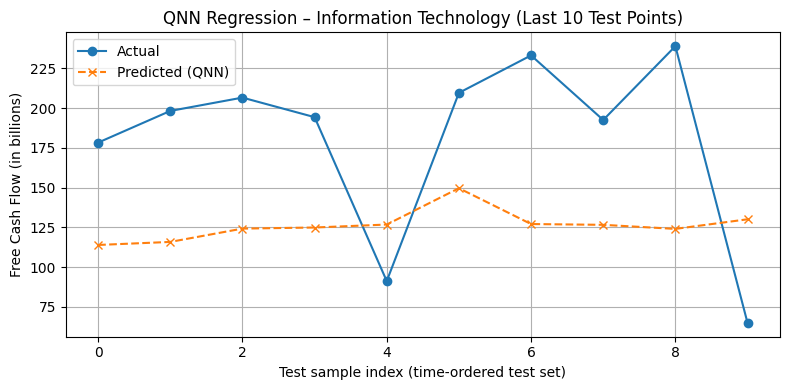

/tmp/ipython-input-57855425.py:7: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(num_features)
/tmp/ipython-input-57855425.py:8: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_features, reps=1)



=== Sector: Consumer Discretionary (72 rows) ===
  Building and training QNN regressor...
  MAE:  54.8719
  R²:   -0.1672


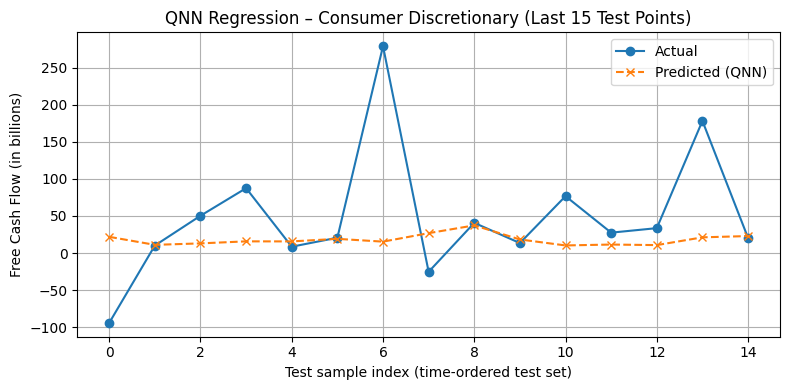

/tmp/ipython-input-57855425.py:7: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(num_features)
/tmp/ipython-input-57855425.py:8: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_features, reps=1)



=== Sector: Other (60 rows) ===
  Building and training QNN regressor...
  MAE:  38.7291
  R²:   -0.0351


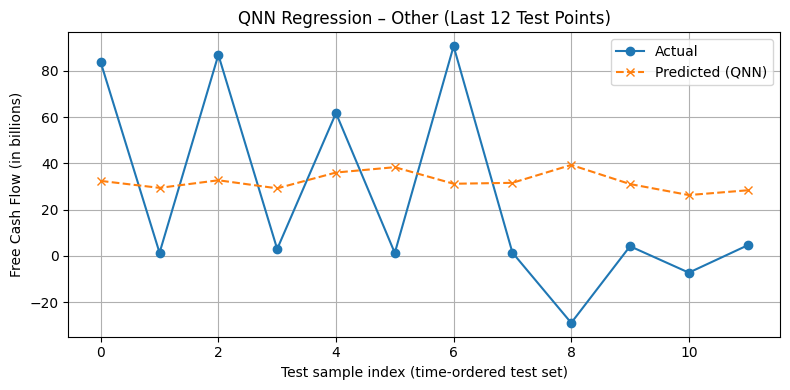


=== Sector: Communication Services (144 rows) ===


/tmp/ipython-input-57855425.py:7: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(num_features)
/tmp/ipython-input-57855425.py:8: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_features, reps=1)


  Building and training QNN regressor...
  MAE:  79.7951
  R²:   -0.4060


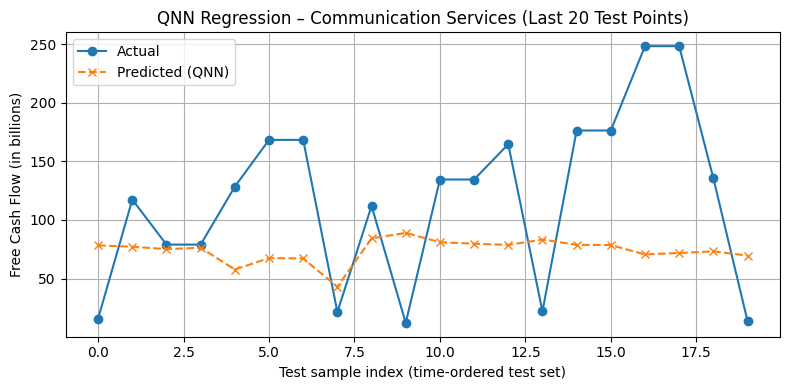


=== Sector: Health Care (50 rows) ===
  Building and training QNN regressor...


/tmp/ipython-input-57855425.py:7: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(num_features)
/tmp/ipython-input-57855425.py:8: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_features, reps=1)


  MAE:  25.3648
  R²:   0.0042


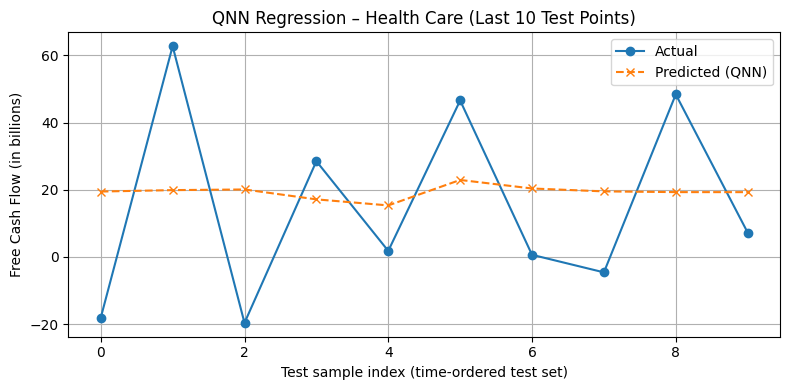

/tmp/ipython-input-57855425.py:7: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(num_features)
/tmp/ipython-input-57855425.py:8: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_features, reps=1)



=== Sector: Financials (108 rows) ===
  Building and training QNN regressor...
  MAE:  306.2930
  R²:   0.0248


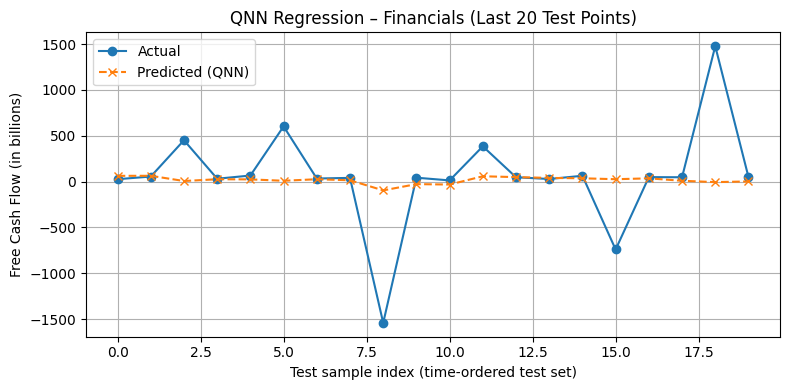

/tmp/ipython-input-57855425.py:7: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(num_features)
/tmp/ipython-input-57855425.py:8: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_features, reps=1)



=== Sector: Energy (36 rows) ===
  Building and training QNN regressor...
  MAE:  33.1171
  R²:   -0.9311


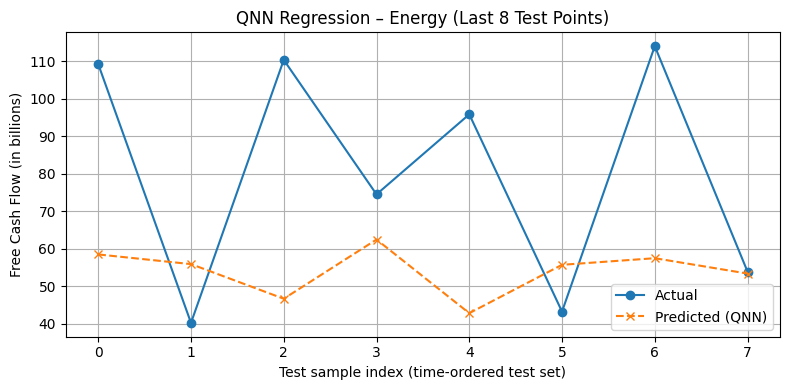

In [13]:
results_qnn = []
PLOT_PER_SECTOR = True   # Set False if you don’t want graphs for every sector

sectors = df_q[SECTOR_COL].dropna().unique()
print("Sectors found in QNN dataset:", sectors)

num_features = len(feature_cols)

for sec in sectors:
    sub = df_q[df_q[SECTOR_COL] == sec].copy()
    n_rows = len(sub)

    print(f"\n=== Sector: {sec} ({n_rows} rows) ===")

    if n_rows < 25:
        print(f"  Skipping {sec}: too few rows.")
        continue

    # Sort by time if available
    if TIME_COL in sub.columns:
        sub = sub.sort_values(TIME_COL)

    # Build X and y
    X = sub[feature_cols].values
    y = sub[TARGET_COL].values

    # Scale features and target within the sector
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_scaled = X_scaler.fit_transform(X)
    y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

    # 80/20 time-based split
    split_idx = int(0.8 * len(X_scaled))
    if split_idx == 0 or split_idx == len(X_scaled):
        print(f"  Skipping {sec}: cannot split into train/test.")
        continue

    X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]

    # Build fresh QNN regressor for this sector
    print("  Building and training QNN regressor...")
    qnn_reg = build_qnn_regressor(num_features=num_features, maxiter=80)

    # Train
    qnn_reg.fit(X_train, y_train)

    # Predict on test
    y_pred_scaled = qnn_reg.predict(X_test)

    # Back-transform to original cash-flow units
    y_test_real = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
    y_pred_real = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    # Metrics
    mae  = mean_absolute_error(y_test_real, y_pred_real)
    #rmse = mean_squared_error(y_test_real, y_pred_real, squared=False)
    r2   = r2_score(y_test_real, y_pred_real)

    print(f"  MAE:  {mae:,.4f}")
    #print(f"  RMSE: {rmse:,.4f}")
    print(f"  R²:   {r2:.4f}")

    results_qnn.append({
        "Sector": sec,
        "n_obs": n_rows,
        "MAE": mae,
        #"RMSE": rmse,
        "R2": r2,
    })

    # Plot: last 20 test points
    if PLOT_PER_SECTOR:
        N = min(20, len(y_test_real))
        plt.figure(figsize=(8, 4))
        plt.plot(y_test_real[-N:], label="Actual", marker="o")
        plt.plot(y_pred_real[-N:], label="Predicted (QNN)", marker="x", linestyle="--")
        plt.title(f"QNN Regression – {sec} (Last {N} Test Points)")
        plt.xlabel("Test sample index (time-ordered test set)")
        plt.ylabel("Free Cash Flow (in billions)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


In [ ]:
results_qnn_df = pd.DataFrame(results_qnn).sort_values("Sector")
results_qnn_df


,Sector,n_obs,MAE,R2
3,Communication Services,144,79.202889,-0.372451
1,Consumer Discretionary,72,53.567212,-0.133087
6,Energy,36,31.749878,-0.704731
5,Financials,108,305.634228,-0.007930
4,Health Care,50,25.619428,-0.010926
0,Information Technology,49,67.763061,-0.659691
2,Other,60,40.679480,-0.079492


In [ ]:
results_qnn_df.to_csv("QNN_Sectorwise_Results.csv", index=False)

from google.colab import files
files.download("QNN_Sectorwise_Results.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>